In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import glob
from sklearn import cluster, metrics, model_selection, ensemble
from scipy import stats as st

import seaborn as sns

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score, accuracy_score


from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif

from statsmodels.graphics.tsaplots import plot_acf

import joblib


In [2]:
data_directory = 'G:/My Drive/kaggle_data/FoG_prediction/'

In [74]:
# Create function for testing models
def test_model(algorithm, X_train, y_train, X_test, y_test, save_path=None):
    
    # Initialize and train the model
    model = algorithm()
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Save the model if a save_path is provided
    if save_path:
        # Ensure that the save path includes a valid file name with extension
        joblib.dump(model, save_path)
        print(f"Model saved to {save_path}")
    
    return f1, accuracy

#### Metadatas

In [4]:
tdcsfog_metadata_df = pd.read_csv(data_directory+"tdcsfog_metadata.csv")
defog_metadata_df = pd.read_csv(data_directory+"defog_metadata.csv")
subjects_df = pd.read_csv(data_directory+"subjects.csv")
events_df = pd.read_csv(data_directory+"events.csv")
tasks_df = pd.read_csv(data_directory+"tasks.csv")
daily_metadata_df = pd.read_csv(data_directory+"daily_metadata.csv")
full_metadata = pd.concat([tdcsfog_metadata_df, defog_metadata_df])

In [5]:
tdcsfog_metadata_df.head()

,Id,Subject,Visit,Test,Medication
0,003f117e14,4dc2f8,3,2,on
1,009ee11563,f62eec,4,2,on
2,011322847a,231c3b,2,2,on
3,01d0fe7266,231c3b,2,1,off
4,024418ba39,fa8764,19,3,on


In [6]:
defog_metadata_df.head()

,Id,Subject,Visit,Medication
0,02ab235146,e1f62e,2,on
1,02ea782681,ae2d35,2,on
2,06414383cf,8c1f5e,2,off
3,092b4c1819,2874c5,1,off
4,0a900ed8a2,0e3d49,2,on


In [7]:
subjects_df.head()

,Subject,Visit,Age,Sex,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ
0,00f674,2.0,63,M,27.0,43.0,49.0,24
1,00f674,1.0,63,M,27.0,31.0,30.0,26
2,02bc69,NaN,69,M,4.0,21.0,NaN,22
3,040587,2.0,75,M,26.0,52.0,69.0,21
4,040587,1.0,75,M,26.0,47.0,75.0,24


In [8]:
events_df.head()

,Id,Init,Completion,Type,Kinetic
0,003f117e14,8.61312,14.7731,Turn,1.0
1,009ee11563,11.38470,41.1847,Turn,1.0
2,009ee11563,54.66470,58.7847,Turn,1.0
3,011322847a,28.09660,30.2966,Turn,1.0
4,01d0fe7266,30.31840,31.8784,Turn,1.0


In [9]:
tasks_df.head()

,Id,Begin,End,Task
0,02ab235146,10.00,190.48,Rest1
1,02ab235146,211.24,271.56,Rest2
2,02ab235146,505.88,522.40,4MW
3,02ab235146,577.96,594.64,4MW-C
4,02ab235146,701.32,715.28,MB1


In [10]:
daily_metadata_df.head()

,Id,Subject,Visit,Beginning of recording [00:00-23:59]
0,00c4c9313d,fba3a3,1,10:19
1,07a96f89ec,7da72f,1,07:30
2,0d1bc672a8,056372,2,08:30
3,0e333c9833,b4bd22,1,11:30
4,164adaed7b,9f72eb,1,13:00


### Load tdcsfog data

In [11]:
# list of all tdcsfog csv file path
tdcs_file_path = glob.glob(os.path.join(data_directory, 'train', 'tdcsfog', '*.csv'), recursive=True)

# Replace backslashes with forward slashes
tdcs_file_path = [path.replace('\\', '/') for path in tdcs_file_path]

print(f'the number of files to be read: {len(tdcs_file_path)}')

the number of files to be read: 833


In [12]:
# Initialize a DataFrame to combine data from multiple CSV files.
tdcsfog_data = pd.DataFrame()

for fp in tdcs_file_path:
    # load data into a variable 'tmp'.
    tmp = pd.read_csv(fp)
    
    # get file Id from csv file name.
    file_id = os.path.basename(fp).replace(".csv", "")

    # Add the file Id as a new column
    tmp['Id'] = file_id 
    
    # concat the data
    tdcsfog_data = pd.concat([tdcsfog_data, tmp]).reset_index(drop=True)

In [13]:
tdcsfog_data['Dataset']='tdcsfog'
tdcsfog_data.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset
0,0,-9.533939,0.566322,-1.413525,0,0,0,003f117e14,tdcsfog
1,1,-9.536140,0.564137,-1.440621,0,0,0,003f117e14,tdcsfog
2,2,-9.529345,0.561765,-1.429332,0,0,0,003f117e14,tdcsfog
3,3,-9.531239,0.564227,-1.415490,0,0,0,003f117e14,tdcsfog
4,4,-9.540825,0.561854,-1.429471,0,0,0,003f117e14,tdcsfog


In [14]:
tdcsfog_data.describe()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
count,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06
mean,9.289467e+03,-9.306317e+00,-2.012513e-01,1.808524e+00,4.315506e-02,2.376979e-01,2.942767e-02
std,1.399893e+04,1.080174e+00,1.269525e+00,2.285849e+00,2.032061e-01,4.256731e-01,1.690020e-01
min,0.000000e+00,-3.552112e+01,-2.616440e+01,-4.782964e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.119000e+03,-9.762402e+00,-9.295446e-01,5.672254e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.310000e+03,-9.363524e+00,-1.722245e-01,1.987101e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.433000e+03,-8.776814e+00,5.752114e-01,3.449026e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,9.707600e+04,2.090695e+01,2.748472e+01,3.033769e+01,1.000000e+00,1.000000e+00,1.000000e+00


### Load defog data

In [15]:
# list of all defog csv file path
defog_file_path = glob.glob(os.path.join(data_directory, 'train', 'defog', '*.csv'), recursive=True)


# Replace backslashes with forward slashes
defog_file_path = [path.replace('\\', '/') for path in defog_file_path]

print(f'the number of files to be read: {len(defog_file_path)}')

the number of files to be read: 91


In [16]:
# Initialize a DataFrame to combine data from multiple CSV files.
defog_data = pd.DataFrame()

for fp in defog_file_path:
    # load data into a variable 'tmp'.
    tmp = pd.read_csv(fp)
    
    # get file Id from csv file name.
    file_id = os.path.basename(fp).replace(".csv", "")

    # Add the file Id as a new column
    tmp['Id'] = file_id 

    # extract data from the time period where Valid and Task are both True.
    tmp = tmp[(tmp['Valid'] == True) & (tmp['Task']==True)]
    tmp = tmp.drop(['Valid', 'Task'], axis=1)
    
    # concat the data
    defog_data = pd.concat([defog_data, tmp]).reset_index(drop=True)

In [17]:
defog_data['Dataset']='defog'
defog_data.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset
0,1000,-0.970018,0.061626,-0.265625,0,0,0,02ea782681,defog
1,1001,-0.984375,0.044497,-0.265625,0,0,0,02ea782681,defog
2,1002,-0.984375,0.029016,-0.265625,0,0,0,02ea782681,defog
3,1003,-0.984375,0.015625,-0.265625,0,0,0,02ea782681,defog
4,1004,-0.984670,0.015330,-0.265625,0,0,0,02ea782681,defog


In [18]:
defog_data.describe()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
count,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06
mean,9.112536e+04,-9.349461e-01,-1.229101e-03,-2.257802e-01,1.222335e-04,1.434604e-01,2.408441e-02
std,7.025916e+04,1.072241e-01,1.401177e-01,2.444683e-01,1.105525e-02,3.505418e-01,1.533113e-01
min,1.000000e+03,-6.024701e+00,-2.115008e+00,-5.118650e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.552900e+04,-9.852707e-01,-8.466136e-02,-3.634808e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.682200e+04,-9.392389e-01,0.000000e+00,-2.500000e-01,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.295620e+05,-8.869629e-01,9.248055e-02,-1.132356e-01,0.000000e+00,0.000000e+00,0.000000e+00
max,4.143870e+05,4.458365e+00,4.524038e+00,4.388132e+00,1.000000e+00,1.000000e+00,1.000000e+00


### Look at AccV, AccML and AccP distributions
### Data is in units of m/s^2 for tdcsfog/ and g for defog/ and notype/ 
### 1 m/s^2 to g-unit = 0.10197 g-unit

#### AccV: Let's look at two distributions (tdcsfog_AccV and defog_AccV) and find whether their probabilities are the same or not.




In [19]:
Const = 0.10197
tdcsfog_AccV = tdcsfog_data['AccV'] * Const
defog_AccV = defog_data['AccV']
print(tdcsfog_AccV.mean())
print(defog_AccV.mean())

-0.9489651004960586
-0.9349461219547196


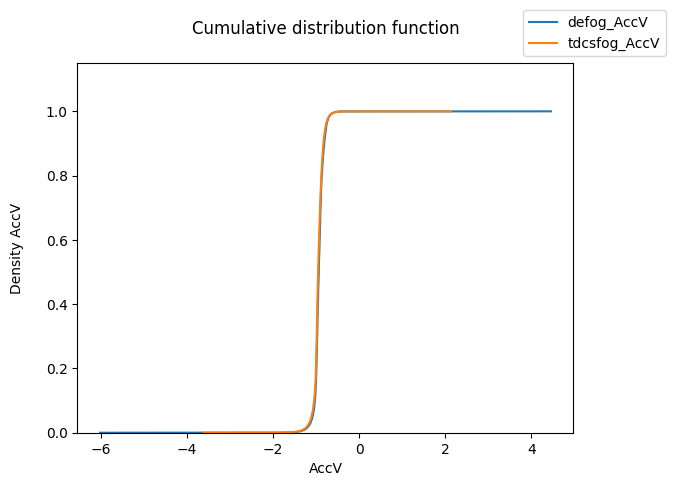

In [20]:
sns.histplot(data=defog_AccV,  bins=len(defog_AccV), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='defog_AccV')

sns.histplot(data=tdcsfog_AccV, bins=len(tdcsfog_AccV), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='tdcsfog_AccV')

plt.xlabel('AccV')
plt.ylabel('Density AccV'+ '\n')
plt.ylim([0.0, 1.15])
plt.legend(bbox_to_anchor=(1.2, 1), loc='lower right')
plt.title('Cumulative distribution function' + '\n')
plt.show()

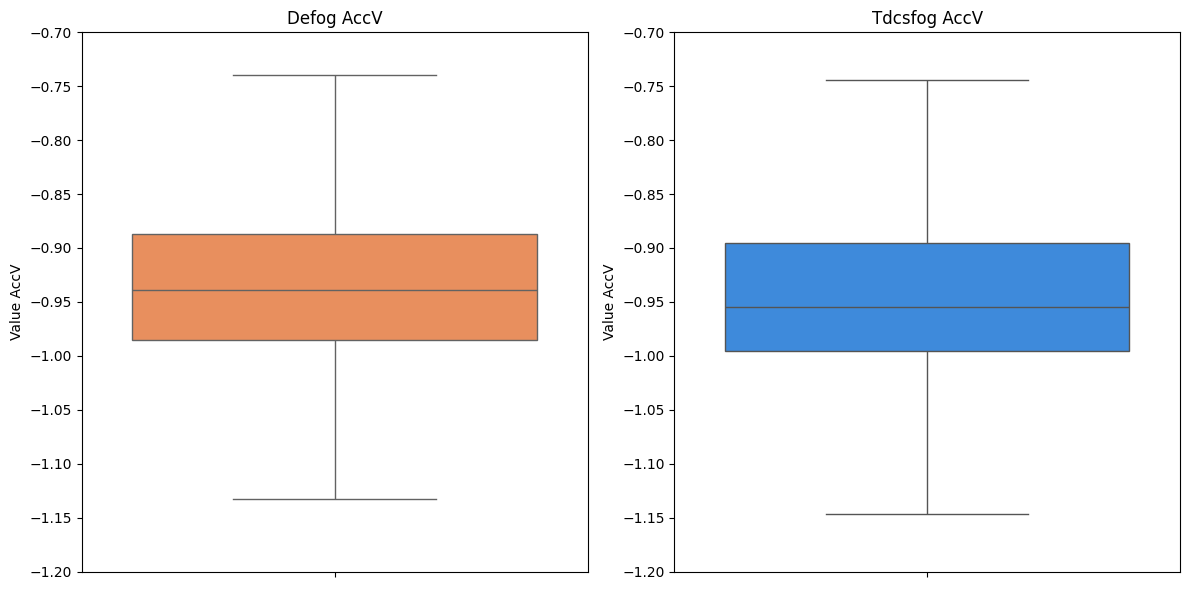

In [21]:
# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
rainbow_palette = sns.color_palette("rainbow", n_colors=10)  

# Boxplot for defog_AccV
sns.boxplot(
    ax=axes[0], 
    data=defog_AccV, 
    color=rainbow_palette[8],
    showfliers=False
)
axes[0].set_title('Defog AccV')
axes[0].set_ylabel('Value AccV')

# Boxplot for tdcsfog_AccV
sns.boxplot(
    ax=axes[1], 
    data=tdcsfog_AccV, 
    color=rainbow_palette[1],
    showfliers=False
)
axes[1].set_title('Tdcsfog AccV')
axes[1].set_ylabel('Value AccV')


# Set y-ticks to be the same across both subplots
y_ticks = sorted(set(axes[0].get_yticks()).union(set(axes[1].get_yticks())))
axes[0].set_yticks(y_ticks)
axes[1].set_yticks(y_ticks)

# Show the plots
plt.tight_layout()
plt.show()

#### AccML: Let's look at two distributions (tdcsfog_AccML and defog_AccML) and find whether their probabilities are the same or not.


In [22]:
tdcsfog_AccML = tdcsfog_data['AccML'] * Const
defog_AccML = defog_data['AccML']
print('mean tdcsfog AccML =', tdcsfog_AccML.mean())
print('mean defog AccML =', defog_AccML.mean())

mean tdcsfog AccML = -0.020521594881632733
mean defog AccML = -0.0012291013734006978


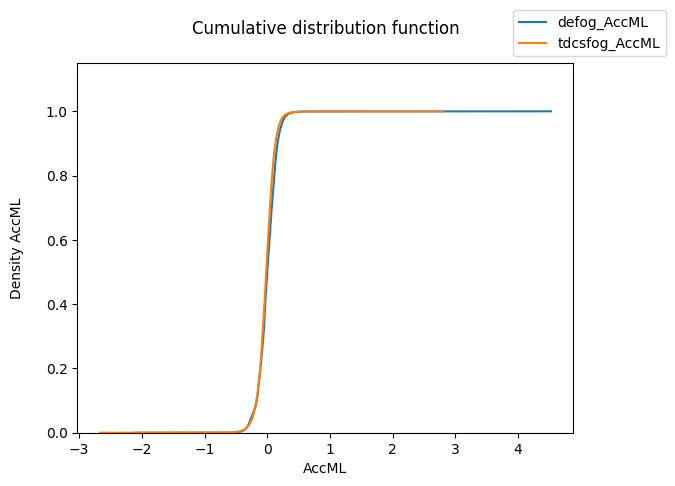

In [23]:
sns.histplot(data=defog_AccML,  bins=len(defog_AccML), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='defog_AccML')

sns.histplot(data=tdcsfog_AccML, bins=len(tdcsfog_AccML), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='tdcsfog_AccML')

plt.xlabel('AccML')
plt.ylabel('Density AccML'+ '\n')
plt.ylim([0.0, 1.15])
plt.legend(bbox_to_anchor=(1.2, 1), loc='lower right')
plt.title('Cumulative distribution function' + '\n')
plt.show()

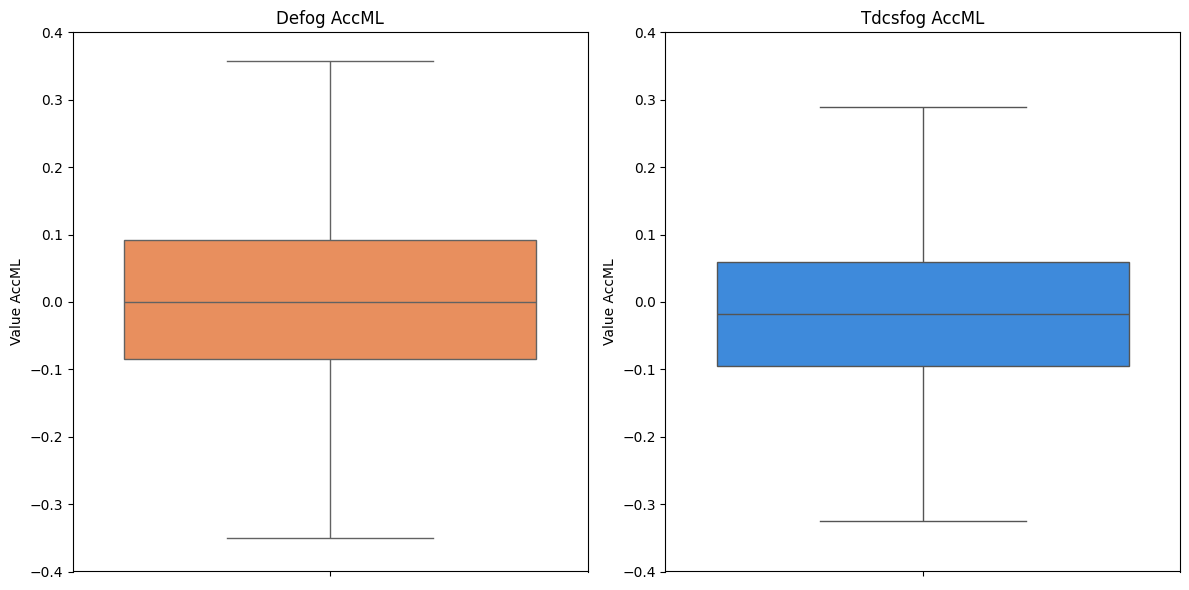

In [24]:
# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Boxplot for defog_AccML
sns.boxplot(
    ax=axes[0], 
    data=defog_AccML, 
    color=rainbow_palette[8],
    showfliers=False
)
axes[0].set_title('Defog AccML')
axes[0].set_ylabel('Value AccML')

# Boxplot for tdcsfog_AccML
sns.boxplot(
    ax=axes[1], 
    data=tdcsfog_AccML, 
    color=rainbow_palette[1],
    showfliers=False
)
axes[1].set_title('Tdcsfog AccML')
axes[1].set_ylabel('Value AccML')


# Set y-ticks to be the same across both subplots
y_ticks = sorted(set(axes[0].get_yticks()).union(set(axes[1].get_yticks())))
axes[0].set_yticks(y_ticks)
axes[1].set_yticks(y_ticks)

# Show the plots
plt.tight_layout()
plt.show()

#### AccAP: Let's look at two distributions (tdcsfog_AccAP and defog_AccAP ) and find whether their probabilities are the same or not.


In [25]:
tdcsfog_AccAP = tdcsfog_data['AccAP'] * Const
defog_AccAP = defog_data['AccAP']
print('mean tdcsfog AccAP =', tdcsfog_AccAP.mean())
print('mean defog AccAP =', defog_AccAP.mean())

mean tdcsfog AccAP = 0.18441523061044188
mean defog AccAP = -0.2257801602045012


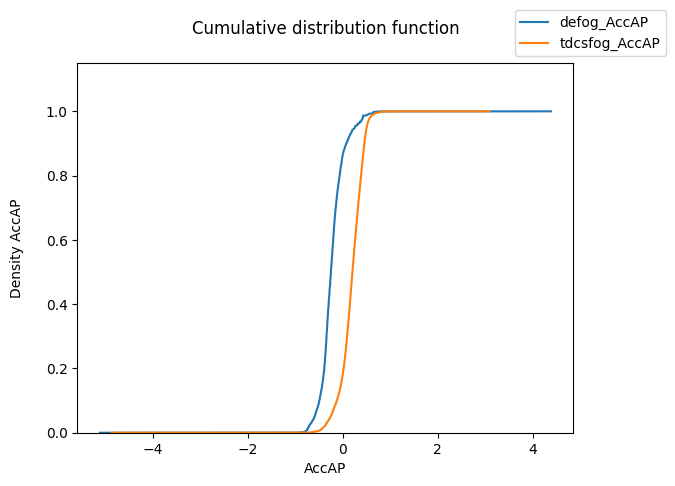

In [26]:
sns.histplot(data=defog_AccAP,  bins=len(defog_AccAP), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='defog_AccAP');

sns.histplot(data=tdcsfog_AccAP, bins=len(tdcsfog_AccAP), stat="density",
      element="step", fill=False, cumulative=True, common_norm=False,legend=True,label='tdcsfog_AccAP');

plt.xlabel('AccAP')
plt.ylabel('Density AccAP'+ '\n')
plt.ylim([0.0, 1.15])
plt.legend(bbox_to_anchor=(1.2, 1), loc='lower right')
plt.title('Cumulative distribution function' + '\n')
plt.show();

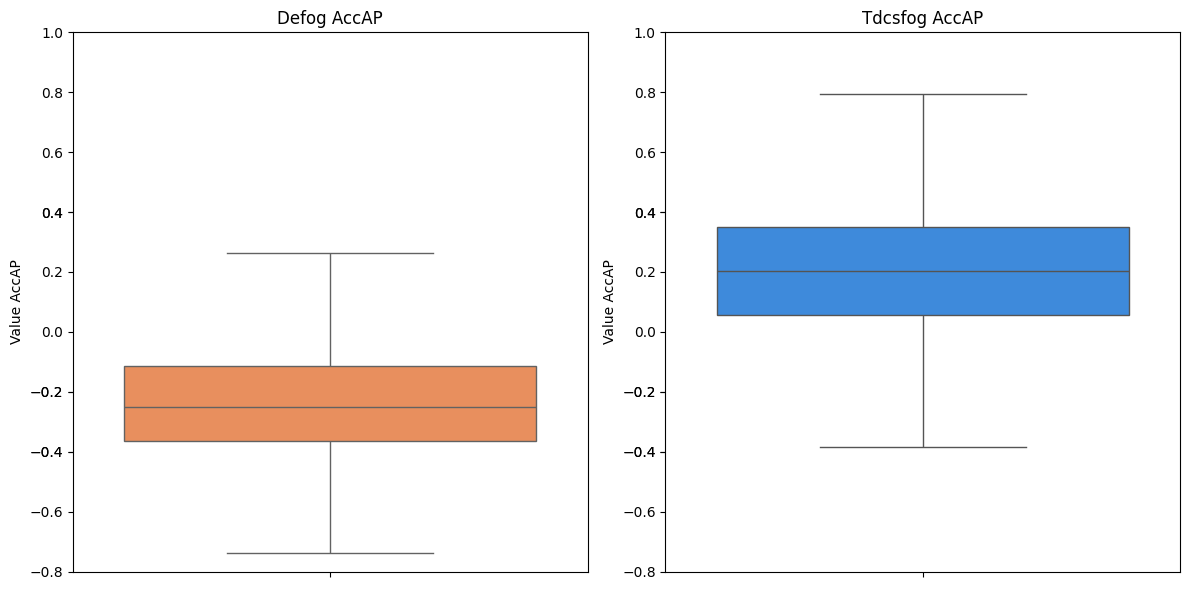

In [27]:
# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Boxplot for defog_AccAP
sns.boxplot(
    ax=axes[0], 
    data=defog_AccAP, 
    color=rainbow_palette[8],
    showfliers=False
)
axes[0].set_title('Defog AccAP')
axes[0].set_ylabel('Value AccAP')

# Boxplot for tdcsfog_AccAP
sns.boxplot(
    ax=axes[1], 
    data=tdcsfog_AccAP, 
    color=rainbow_palette[1],
    showfliers=False
)
axes[1].set_title('Tdcsfog AccAP')
axes[1].set_ylabel('Value AccAP')

# Set y-ticks to be the same across both subplots
y_ticks = sorted(set(axes[0].get_yticks()).union(set(axes[1].get_yticks())))
axes[0].set_yticks(y_ticks)
axes[1].set_yticks(y_ticks)

# Show the plots
plt.tight_layout()
plt.show()

### Statistical function

In [28]:
def t_test_verbose(a, sample2=None, mean=None, fn=None):
    abar = a.mean()
    avar = a.var(ddof=1)  
    na = a.size
    adof = na - 1
    conf_int = st.t.interval(0.95, len(a)-1, 
                                loc=np.mean(a), scale=st.sem(a))

    if type(a) == type(sample2):
        bbar = sample2.mean()
        bvar = sample2.var(ddof=1)
        nb = sample2.size
        bdof = nb - 1

        dof = (avar/na + bvar/nb)**2 /   \
              (avar**2/(na**2*adof) + bvar**2/(nb**2*bdof))
        return {'p-value'           : 
                   fn(a, sample2, equal_var=False).pvalue,  
                'degrees of freedom       ' : dof,  #t_test(a, b),   
                'confidential interval 95%' : conf_int,         
                'n1             ' : a.count(),
                'n2             ' : sample2.count(),
                'average tdcsfog' : a.mean(),
                'average defog'   : sample2.mean(),
                'variance tdcsfog ' : a.var(),
                'variance defog ' : sample2.var(),
                't-statistic' : fn( a, sample2, equal_var=False ).statistic} 

#### Statistical significance AccV
#### H0: Distribution of defog AccP is NOT the same as tdcsfog

#### H1: Distribution of defog AccP is the same as tdcsfog

In [29]:
results_AccV = st.ttest_ind(tdcsfog_AccV, defog_AccV)
alpha_V = 0.05
print('p-value:', results_AccV.pvalue)
if results_AccV.pvalue < alpha_V:
    print('Reject H0: probably the same distributions')
else:
    print('Cannot reject H0: probably different distribution') 

p-value: 0.0
Reject H0: probably the same distributions


In [30]:
pd.Series(t_test_verbose(tdcsfog_AccV, sample2=defog_AccV, fn=st.ttest_ind))


p-value                                                             0.0
degrees of freedom                                       8729837.021288
confidential interval 95%    (-0.9490463330036306, -0.9488838679884867)
n1                                                              7062672
n2                                                              4090530
average tdcsfog                                               -0.948965
average defog                                                 -0.934946
variance tdcsfog                                               0.012132
variance defog                                                 0.011497
t-statistic                                                 -208.326185
dtype: object

#### Statistical significance AccML
#### H0: Distribution of defog AccML is NOT the same as tdcsfog

#### H1: Distribution of defog AccML is the same as tdcsfog

In [31]:
results_AccML = st.ttest_ind(tdcsfog_AccML, defog_AccML)
alpha_ML = 0.05
print('p-value:', results_AccML.pvalue)
if results_AccML.pvalue < alpha_ML:
    print('Reject H0: probably the same distributions')
else:
    print('Cannot reject H0: probably different distribution') 

p-value: 0.0
Reject H0: probably the same distributions


In [32]:
pd.Series(t_test_verbose(tdcsfog_AccML, sample2=defog_AccML, fn=st.ttest_ind))


p-value                                                                0.0
degrees of freedom                                          8002029.155936
confidential interval 95%    (-0.02061706715111597, -0.020426122612149496)
n1                                                                 7062672
n2                                                                 4090530
average tdcsfog                                                  -0.020522
average defog                                                    -0.001229
variance tdcsfog                                                  0.016758
variance defog                                                    0.019633
t-statistic                                                    -227.801298
dtype: object

#### Statistical significance AccAP
#### H0: Distribution of defog AccAP is NOT the same as tdcsfog

#### H1: Distribution of defog AccAP is the same as tdcsfog

In [33]:
results_AP = st.ttest_ind(tdcsfog_AccAP, defog_AccAP)
alpha_AP = 0.05
print('p-value:', results_AP.pvalue)
if results_AP.pvalue < alpha_AP:
    print('Reject H0: probably the same distributions')
else:
    print('Cannot reject H0: probably different distribution')  

p-value: 0.0
Reject H0: probably the same distributions


In [34]:
pd.Series(t_test_verbose(tdcsfog_AccAP, sample2=defog_AccAP, fn=st.ttest_ind))


p-value                                                            0.0
degrees of freedom                                       8213201.81071
confidential interval 95%    (0.1842433275707617, 0.18458713365012205)
n1                                                             7062672
n2                                                             4090530
average tdcsfog                                               0.184415
average defog                                                 -0.22578
variance tdcsfog                                               0.05433
variance defog                                                0.059765
t-statistic                                                2746.682215
dtype: object

### Conclusion: As we can see distributions of AccP, AccV and AccML probably are the same

### After bringing all the values ​​to a single dimension, we can safely combine the data


In [35]:
dict_col = ['AccV', 'AccML', 'AccAP']

for col in dict_col:
    tdcsfog_data[col] = tdcsfog_data[col] * Const

In [36]:
train_df = pd.concat([tdcsfog_data, defog_data]).reset_index(drop=True)
train_df.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset
0,0,-0.972176,0.057748,-0.144137,0,0,0,003f117e14,tdcsfog
1,1,-0.972400,0.057525,-0.146900,0,0,0,003f117e14,tdcsfog
2,2,-0.971707,0.057283,-0.145749,0,0,0,003f117e14,tdcsfog
3,3,-0.971900,0.057534,-0.144337,0,0,0,003f117e14,tdcsfog
4,4,-0.972878,0.057292,-0.145763,0,0,0,003f117e14,tdcsfog


In [38]:
tdcsfog_sample_file = pd.read_csv('G:/My Drive/kaggle_data/FoG_prediction/train/tdcsfog/003f117e14.csv')
tdcsfog_sample_file.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
0,0,-9.533939,0.566322,-1.413525,0,0,0
1,1,-9.536140,0.564137,-1.440621,0,0,0
2,2,-9.529345,0.561765,-1.429332,0,0,0
3,3,-9.531239,0.564227,-1.415490,0,0,0
4,4,-9.540825,0.561854,-1.429471,0,0,0


### Lag Plot

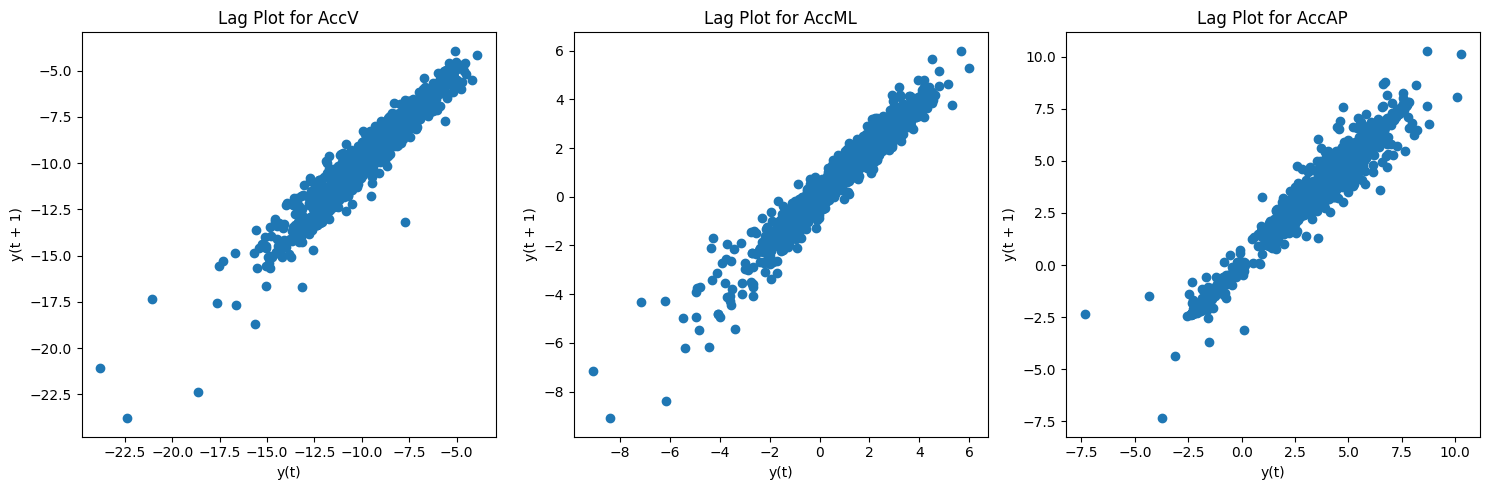

In [39]:
# Extract 'AccV', 'AccML', 'AccAP' data 
accV_data = tdcsfog_sample_file['AccV']
accML_data = tdcsfog_sample_file['AccML']
accAP_data = tdcsfog_sample_file['AccAP']

# Create DataFrames for 'AccV', 'AccML', 'AccAP' data
df_accV = pd.DataFrame({'AccV': accV_data})
df_accML = pd.DataFrame({'AccML': accML_data})
df_accAP = pd.DataFrame({'AccAP': accAP_data})

# Create lag plots for each axis
plt.figure(figsize=(15, 5))

# lag plot for 'AccV'
plt.subplot(1, 3, 1)
pd.plotting.lag_plot(df_accV['AccV'], lag=1)
plt.title('Lag Plot for AccV')

# lag plot for 'AccML'
plt.subplot(1, 3, 2)
pd.plotting.lag_plot(df_accML['AccML'], lag=1)
plt.title('Lag Plot for AccML')

# lag plot for 'AccAP'
plt.subplot(1, 3, 3)
pd.plotting.lag_plot(df_accAP['AccAP'], lag=1)
plt.title('Lag Plot for AccAP')

plt.tight_layout()
plt.show()

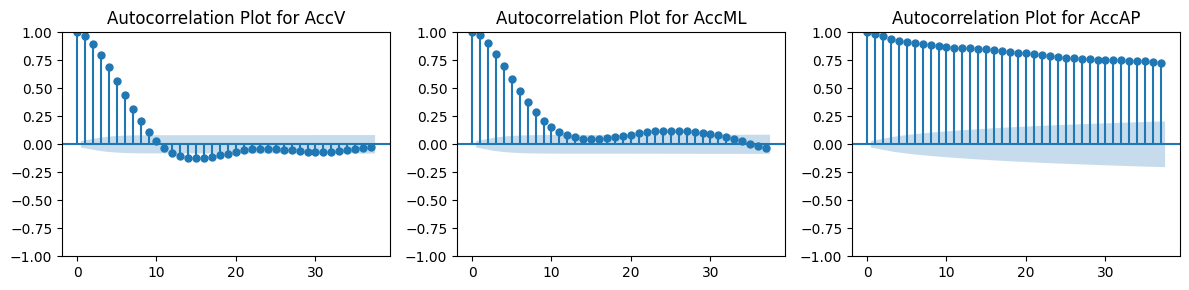

In [40]:
# Extract 'AccV', 'AccML', 'AccAP' data 
accV_data = tdcsfog_sample_file['AccV']
accML_data = tdcsfog_sample_file['AccML']
accAP_data = tdcsfog_sample_file['AccAP']

# Create DataFrames for 'AccV', 'AccML', 'AccAP' data
df_accV = pd.DataFrame({'AccV': accV_data})
df_accML = pd.DataFrame({'AccML': accML_data})
df_accAP = pd.DataFrame({'AccAP': accAP_data})

# Create autocorrelation plots for each axis
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

# Autocorrelation plot for 'AccV'
plot_acf(df_accV['AccV'], ax=axes[0])
axes[0].set_title('Autocorrelation Plot for AccV')

# Autocorrelation plot for 'AccML'
plot_acf(df_accML['AccML'], ax=axes[1])
axes[1].set_title('Autocorrelation Plot for AccML')

# Autocorrelation plot for 'AccAP'
plot_acf(df_accAP['AccAP'], ax=axes[2])
axes[2].set_title('Autocorrelation Plot for AccAP')

plt.tight_layout()
plt.show()

### Mutual Information Feature Selection

#### Feature engineering
#### For tasks_data, we will calculate the duration of each task by subtracting the Begin time from the End time, and then obtain the sum of durations for each task and each unique Id value. Then we will apply a k-means clustering algorithm with 10 clusters on the numeric columns.
#### For subjects_data, we will group the data by Subject column and computing the median values for the selected columns. And then we will also apply a k-means clustering algorithm with 10 clusters on the numeric columns.

In [43]:
tasks_df['Duration'] = tasks_df['End'] - tasks_df['Begin']

tasks_data = pd.pivot_table(tasks_df, values=['Duration'],
                                index=['Id'], columns=['Task'],
                                aggfunc='sum', fill_value=0)

tasks_data.columns = [c[-1] for c in tasks_data.columns]
tasks_data = tasks_data.reset_index()

tasks_data['t_kmeans'] = KMeans(n_clusters=10, random_state=42, n_init=10) \
                    .fit_predict(tasks_data[tasks_data.columns[1:]])


In [44]:
tasks_data.head()

,Id,4MW,4MW-C,Hotspot1,Hotspot1-C,Hotspot2,Hotspot2-C,MB1,MB10,MB11,...,MB9,Rest1,Rest2,TUG-C,TUG-DT,TUG-ST,Turning-C,Turning-DT,Turning-ST,t_kmeans
0,02ab235146,16.520,16.680,16.760,16.240,53.920,64.600,13.960,17.960,17.40,...,30.80,180.48,60.32,38.440,47.920,36.240,21.920,46.400,23.320,3
1,02ea782681,11.618,11.796,11.525,11.692,8.329,9.032,3.469,6.624,6.23,...,30.65,0.00,0.00,18.343,19.932,20.130,18.042,21.588,18.698,7
2,06414383cf,24.860,41.584,25.885,0.000,38.642,0.000,0.000,0.000,0.00,...,0.00,0.00,0.00,0.000,44.832,33.867,0.000,83.837,124.299,1
3,092b4c1819,13.664,0.000,15.409,0.000,34.834,0.000,0.000,0.000,0.00,...,0.00,0.00,0.00,0.000,30.166,23.347,0.000,45.025,39.351,7
4,0a900ed8a2,11.720,11.840,10.600,10.720,43.171,41.160,1.760,21.040,10.56,...,30.52,180.88,60.32,18.083,25.000,19.920,18.699,18.200,16.880,3


In [45]:
subjects_data = subjects_df.fillna(0).groupby('Subject') \
    [['Visit', 'Age', 'YearsSinceDx', 'UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']].median()
subjects_data = subjects_data.reset_index()

subjects_data['s_kmeans'] = KMeans(n_clusters=10, random_state=42, n_init=10) \
                    .fit_predict(subjects_data[subjects_data.columns[1:]])

In [46]:
subjects_df.head()

,Subject,Visit,Age,Sex,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ
0,00f674,2.0,63,M,27.0,43.0,49.0,24
1,00f674,1.0,63,M,27.0,31.0,30.0,26
2,02bc69,NaN,69,M,4.0,21.0,NaN,22
3,040587,2.0,75,M,26.0,52.0,69.0,21
4,040587,1.0,75,M,26.0,47.0,75.0,24


In [47]:
subjects_data.head()

,Subject,Visit,Age,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ,s_kmeans
0,00f674,1.5,63.0,27.0,37.0,39.5,25.0,8
1,02bc69,0.0,69.0,4.0,21.0,0.0,22.0,5
2,040587,1.5,75.0,26.0,49.5,72.0,22.5,7
3,056372,2.0,69.0,13.0,44.0,50.0,22.0,1
4,07285e,0.0,58.0,1.0,18.0,26.0,10.0,0


In [48]:
train_df = train_df.merge(full_metadata, on='Id', how='inner') \
                        .merge(tasks_data[['Id','t_kmeans']], how='left', on='Id').fillna(-1) \
                        .merge(subjects_data.drop('Visit', axis=1),
                                       on='Subject', how='left').fillna(-1)
train_df.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset,Subject,Visit,Test,Medication,t_kmeans,Age,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ,s_kmeans
0,0,-0.972176,0.057748,-0.144137,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on,-1.0,68.0,9.0,17.0,15.0,15.0,0
1,1,-0.972400,0.057525,-0.146900,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on,-1.0,68.0,9.0,17.0,15.0,15.0,0
2,2,-0.971707,0.057283,-0.145749,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on,-1.0,68.0,9.0,17.0,15.0,15.0,0
3,3,-0.971900,0.057534,-0.144337,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on,-1.0,68.0,9.0,17.0,15.0,15.0,0
4,4,-0.972878,0.057292,-0.145763,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on,-1.0,68.0,9.0,17.0,15.0,15.0,0


In [49]:
train_df[train_df.Dataset == 'defog'].index[0]

7062672

#### Let's take the first one million rows of the full_data dataframe that will correcpond to tdscfog dataset rows, and another one million rows (starting from index 7,062,672 to 8,062,672) will be from the defog dataset. This will give us a balanced final dataset with equal number of samples from both datasets.

In [50]:
train_df_sample = pd.concat([train_df[:1000_000], train_df[7_062_672:8_062_672]])
train_df_sample.shape

(2000000, 20)

In [51]:
# Create multiclass event type column
train_df_sample['target'] = 'Normal'
targets = ['StartHesitation', 'Turn', 'Walking']
for target in targets:
    train_df_sample.loc[train_df_sample[target] == 1, 'target'] = target
    
train_df_sample.Medication = np.where(train_df_sample.Medication == 'off', 0, 1)

In [52]:
# Create new features based on accelerometer data columns and returns the updated dataframe
def create_features(df):
    acc_cols = ['AccV', 'AccML', 'AccAP']

    for acc in acc_cols:
        df[f'{acc}_lag_2'] = df.groupby('Id')[acc].shift(2).fillna(method="backfill")
        df[f'{acc}_lag_3'] = df.groupby('Id')[acc].shift(3).fillna(method="backfill")
        df[f'{acc}_lag_4'] = df.groupby('Id')[acc].shift(4).fillna(method="backfill")
        df[f'{acc}_lag_5'] = df.groupby('Id')[acc].shift(5).fillna(method="backfill")

        df[f'{acc}_cumsum'] = (df[acc]).groupby(df['Id']).cumsum()

        df[f'{acc}_first_value'] = df.groupby('Id')[acc].transform('first')
        df[f'{acc}_last_value'] = df.groupby('Id')[acc].transform('last')

        df[f'{acc}_mean'] = df.groupby('Id')[acc].transform('mean')
        df[f'{acc}_median'] = df.groupby('Id')[acc].transform('median')
        df[f'{acc}_std'] = df.groupby('Id')[acc].transform('std')

        df[f'{acc}_min'] = df.groupby('Id')[acc].transform('min')
        df[f'{acc}_max'] = df.groupby('Id')[acc].transform('max')

        df[f'{acc}_delta'] = df[f'{acc}_max'] - df[f'{acc}_min']
        for lag in [1,2,3]:
            df[f'ma_{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
            df[f'ma{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
            df[f'ma_{lag}_{acc}'] = df[acc].rolling(lag).mean().fillna(method="backfill")
        
    return df

In [53]:
# Apply the above function to our dataset
train_df_sample = create_features(train_df_sample)

C:\Users\35262\AppData\Local\Temp\ipykernel_33460\3785893945.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'{acc}_lag_2'] = df.groupby('Id')[acc].shift(2).fillna(method="backfill")
C:\Users\35262\AppData\Local\Temp\ipykernel_33460\3785893945.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'{acc}_lag_3'] = df.groupby('Id')[acc].shift(3).fillna(method="backfill")
C:\Users\35262\AppData\Local\Temp\ipykernel_33460\3785893945.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f'{acc}_lag_4'] = df.groupby('Id')[acc].shift(4).fillna(method="backfill")
C:\Users\35262\AppData\Local\Temp\ipykernel_33460\3785893945.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. 

In [54]:
# Assign variables with predictors and target
X = train_df_sample.drop(['Id', 'Dataset', 'Test', 'Subject', 'UPDRSIII_Off',
                               'StartHesitation', 'Turn', 'Walking'], axis=1).copy()
y = X.pop('target')

In [55]:
# Check the missing values in our X dataset
X.isna().sum()[X.isna().sum() > 0]

Series([], dtype: int64)

In [56]:
# Check the categorical variables in our X dataset
X.dtypes[X.dtypes == object]

Series([], dtype: object)

#### Calculating Mutual information scores¶

In [57]:
discrete_features = X.dtypes == int

# Calculate MI scores for the features in X with respect to the target variable y
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

# Apply this function to our data
mi_scores = make_mi_scores(X, y, discrete_features)

In [58]:
# Show 10 features with the highest MI score
mi_scores.to_frame().head(10)

,MI Scores
AccML_min,0.275162
AccML_delta,0.274930
AccAP_min,0.274407
AccV_delta,0.274295
AccV_mean,0.274127
AccV_min,0.274120
AccAP_last_value,0.273655
AccV_last_value,0.273616
AccML_max,0.273335
AccAP_median,0.273161


C:\Users\35262\AppData\Local\Temp\ipykernel_33460\255570387.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=scores.values, y=scores.index, palette="coolwarm", orient='h')


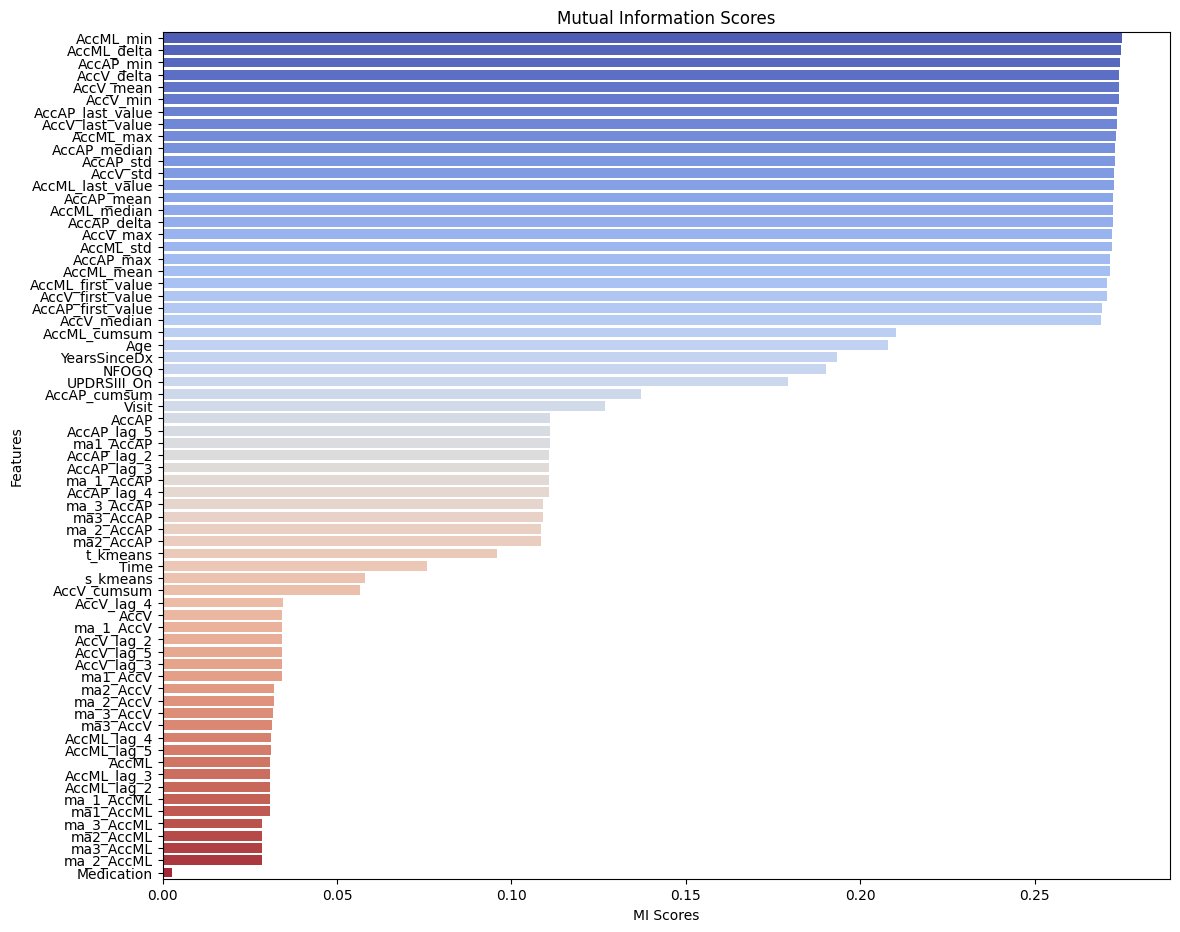

In [59]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(13, 11))
    ax = sns.barplot(x=scores.values, y=scores.index, palette="coolwarm", orient='h')
    ax.set_title("Mutual Information Scores")
    ax.set_xlabel("MI Scores")
    ax.set_ylabel("Features")
    plt.show()

plot_mi_scores(mi_scores)
plt.show()

#### the difference between the maximum and minimum values of all accelerometer data columns: AccV_delta, AccAP_delta, AccML_delta, the minimum and maximum values of the accelerometer columns, especially AccML_min, AccAP_min, AccML_max, the mean, median, and standard deviation of the columns, especially AccV_median, AccV_mean, AccV_std, the first and last values of the columns, especially AccV_last_value, the cumulative sum of the accelerometer data columns. Other highly informative features include Age, UPDRSIII_On, and NFOGQ which respectively represent the age of patients, the motor score of patients when taking medication, and the presence of freezing of gait.

#### On the other hand, the most uninformative features are the Medication status column, the moving average features using the rolling method such as ma_2_AccML, and the lagged versions of accelerometer data, such as AccML_lag_3. These features do not seem to have a strong relationship with the target variable and may not be useful in predicting it.

#### Overall, these results can guide us in selecting the most relevant features for building our predictive model.

#### Turn

In [72]:
# Create features and targets
drop_cols = ['Time', 'StartHesitation', 'Turn', 'Walking', 'Id', 'Dataset', 'target', 'Subject']

X = train_df_sample.drop(drop_cols, axis=1)
y = train_df_sample["Turn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train.shape

(1400000, 70)

##### XGBoost

In [82]:

# Test the model and save it to the constructed path
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/turn/xgb_model.pkl'

In [84]:

%%time
f1_xgb, accuracy_xgb = test_model(XGBClassifier, X_train, y_train, X_test, y_test, save_path=save_path)

print(f"XGBClassifier | F1 score - {f1_xgb}, | Accuracy - {accuracy_xgb}")

Model saved to D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/turn/xgb_model.pkl
XGBClassifier | F1 score - 0.9390160339865699, | Accuracy - 0.9807166666666667
CPU times: total: 2min 14s
Wall time: 20.7 s


##### LightBGM

In [85]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/turn/lbgm_model.pkl'

In [86]:
%%time

f1_lgbm, accuracy_lgbm = test_model(LGBMClassifier, X_train, y_train, X_test, y_test, save_path=save_path)

print(f"LGBMClassifier | F1 score - {f1_lgbm}, | Accuracy - {accuracy_lgbm}") 

[LightGBM] [Info] Number of positive: 222885, number of negative: 1177115
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.426349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12881
[LightGBM] [Info] Number of data points in the train set: 1400000, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.159204 -> initscore=-1.664166
[LightGBM] [Info] Start training from score -1.664166
Model saved to D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/turn/lbgm_model.pkl
LGBMClassifier | F1 score - 0.90065906061109, | Accuracy - 0.969075
CPU times: total: 2min 38s
Wall time: 25.7 s


##### CatBoostClassifier

In [87]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/turn/cb_model.pkl'

In [88]:
%%time

f1_cb, accuracy_cb = test_model(CatBoostClassifier, X_train, y_train, X_test, y_test , save_path=save_path)

print(f"CatBoostClassifier | F1 score - {f1_cb}, | Accuracy - {accuracy_cb}")

Learning rate set to 0.227159
0:	learn: 0.5088683	total: 498ms	remaining: 8m 17s
1:	learn: 0.4053862	total: 860ms	remaining: 7m 9s
2:	learn: 0.3483247	total: 1.17s	remaining: 6m 29s
3:	learn: 0.3136290	total: 1.5s	remaining: 6m 13s
4:	learn: 0.2899778	total: 1.78s	remaining: 5m 55s
5:	learn: 0.2740106	total: 2.07s	remaining: 5m 43s
6:	learn: 0.2606034	total: 2.46s	remaining: 5m 49s
7:	learn: 0.2463053	total: 2.78s	remaining: 5m 45s
8:	learn: 0.2393725	total: 3.06s	remaining: 5m 36s
9:	learn: 0.2315005	total: 3.38s	remaining: 5m 34s
10:	learn: 0.2247983	total: 3.77s	remaining: 5m 38s
11:	learn: 0.2198388	total: 4.11s	remaining: 5m 38s
12:	learn: 0.2164177	total: 4.37s	remaining: 5m 31s
13:	learn: 0.2116290	total: 4.77s	remaining: 5m 35s
14:	learn: 0.2091665	total: 5.04s	remaining: 5m 31s
15:	learn: 0.2040373	total: 5.34s	remaining: 5m 28s
16:	learn: 0.2013421	total: 5.71s	remaining: 5m 30s
17:	learn: 0.1989967	total: 6.03s	remaining: 5m 28s
18:	learn: 0.1955677	total: 6.37s	remaining: 5

In [89]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)
dummy_clf.predict(X_train)
accuracy_dummy = dummy_clf.score(X_train, y_train)

print("DummyClassifier | accuracy" , accuracy_dummy)

DummyClassifier | accuracy 0.8407964285714286


In [91]:
# Create summary table
index = ["CatBoostClassifier",
         "XGBClassifier", 
         "LGBMClassifier",
         "DummyClassifier",
        ]

data = {'F1 score':[round(f1_cb,5),
                    round(f1_xgb,5),
                    round(f1_lgbm,5),
                    "-"],
        'Accuracy':[round(accuracy_cb, 5),
                    round(accuracy_xgb ,5),
                    round(accuracy_lgbm, 5),
                    round(accuracy_dummy, 5)],
        
        }

turn_res= pd.DataFrame(data=data, index=index)
turn_res

,F1 score,Accuracy
CatBoostClassifier,0.96563,0.98909
XGBClassifier,0.93902,0.98072
LGBMClassifier,0.90066,0.96908
DummyClassifier,-,0.84080


#### walking

In [92]:
# Create features and targets
drop_cols = ['Time', 'StartHesitation', 'Turn', 'Walking', 'Id', 'Dataset', 'target', 'Subject']

X = train_df_sample.drop(drop_cols, axis=1)
y_walking = train_df_sample["Walking"]

X_train_walk, X_test_walk, y_train_walk, y_test_walk = train_test_split(X, y_walking, test_size=0.3, random_state=42, stratify=y_walking)

X_train_walk.shape

(1400000, 70)

In [93]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/walking/xgb_model.pkl'

In [94]:

%%time

f1_xgb_walk, accuracy_xgb_walk = test_model(XGBClassifier, X_train_walk, y_train_walk, X_test_walk, y_test_walk, save_path = save_path)

print(f"XGBClassifier | F1 score - {f1_xgb_walk}, | Accuracy - {accuracy_xgb_walk}")

Model saved to D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/walking/xgb_model.pkl
XGBClassifier | F1 score - 0.9805607034422933, | Accuracy - 0.9991783333333333
CPU times: total: 2min 20s
Wall time: 24.5 s


In [95]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/walking/lgbm_model.pkl'

In [96]:
%%time

f1_lgbm_walk, accuracy_lgbm_walk = test_model(LGBMClassifier, X_train_walk, y_train_walk, X_test_walk, y_test_walk, save_path=save_path)

print(f"LGBMClassifier | F1 score - {f1_lgbm_walk}, | Accuracy - {accuracy_lgbm_walk}") 

[LightGBM] [Info] Number of positive: 29812, number of negative: 1370188
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.451313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12881
[LightGBM] [Info] Number of data points in the train set: 1400000, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.021294 -> initscore=-3.827792
[LightGBM] [Info] Start training from score -3.827792
Model saved to D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/walking/lgbm_model.pkl
LGBMClassifier | F1 score - 0.9759182871734433, | Accuracy - 0.9989783333333333
CPU times: total: 2min 29s
Wall time: 30.7 s


In [97]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/walking/cb_model.pkl'

In [98]:
%%time

f1_cb_walk, accuracy_cb_walk = test_model(CatBoostClassifier, X_train_walk, y_train_walk, X_test_walk, y_test_walk, save_path=save_path)

print(f"CatBoostClassifier | F1 score - {f1_cb_walk}, | Accuracy - {accuracy_cb_walk}")

Learning rate set to 0.227159
0:	learn: 0.2442947	total: 353ms	remaining: 5m 52s
1:	learn: 0.1083036	total: 687ms	remaining: 5m 42s
2:	learn: 0.0646621	total: 1.05s	remaining: 5m 49s
3:	learn: 0.0428314	total: 1.37s	remaining: 5m 41s
4:	learn: 0.0315836	total: 1.68s	remaining: 5m 34s
5:	learn: 0.0257398	total: 2.01s	remaining: 5m 33s
6:	learn: 0.0236059	total: 2.32s	remaining: 5m 29s
7:	learn: 0.0211392	total: 2.83s	remaining: 5m 51s
8:	learn: 0.0199082	total: 3.23s	remaining: 5m 56s
9:	learn: 0.0189118	total: 3.58s	remaining: 5m 53s
10:	learn: 0.0178929	total: 3.86s	remaining: 5m 47s
11:	learn: 0.0152429	total: 4.27s	remaining: 5m 51s
12:	learn: 0.0146897	total: 4.63s	remaining: 5m 51s
13:	learn: 0.0141026	total: 5.06s	remaining: 5m 56s
14:	learn: 0.0135065	total: 5.52s	remaining: 6m 2s
15:	learn: 0.0130213	total: 5.93s	remaining: 6m 4s
16:	learn: 0.0125258	total: 6.42s	remaining: 6m 11s
17:	learn: 0.0121251	total: 6.79s	remaining: 6m 10s
18:	learn: 0.0119033	total: 7.18s	remaining: 6

In [99]:

dummy_clf_walk = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf_walk.fit(X_train_walk, y_train_walk)
dummy_clf_walk.predict(X_train_walk)
accuracy_dummy_walk = dummy_clf_walk.score(X_train_walk, y_train_walk)

print("DummyClassifier | accuracy" , accuracy_dummy_walk)

DummyClassifier | accuracy 0.9787057142857143


In [100]:
# Create summary table
index = ["CatBoostClassifier",
         "XGBClassifier", 
         "LGBMClassifier",
         "DummyClassifier",
        ]

data = {'F1 score':[round(f1_cb_walk,5),
                    round(f1_xgb_walk,5),
                    round(f1_lgbm_walk,5),
                    "-"],
        'Accuracy':[round(accuracy_cb_walk, 5),
                    round(accuracy_xgb_walk ,5),
                    round(accuracy_lgbm_walk, 5),
                    round(accuracy_dummy_walk, 5)]
        }

walking_res= pd.DataFrame(data=data, index=index)
walking_res

,F1 score,Accuracy
CatBoostClassifier,0.98407,0.99933
XGBClassifier,0.98056,0.99918
LGBMClassifier,0.97592,0.99898
DummyClassifier,-,0.97871


### Start Hesisation

In [101]:
# Create features and targets
drop_cols = ['Time', 'StartHesitation', 'Turn', 'Walking', 'Id', 'Dataset', 'target', 'Subject']

X = train_df_sample.drop(drop_cols, axis=1)
y_StartHesitation = train_df_sample["StartHesitation"]

X_train_StartHesitation, X_test_StartHesitation, y_train_StartHesitation, y_test_StartHesitation = train_test_split(X, y_StartHesitation, test_size=0.3, random_state=42, stratify=y_StartHesitation)

X_train_StartHesitation.shape

(1400000, 70)

In [102]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/startHesitation/xgb_model.pkl'

In [103]:

%%time

f1_xgb_StartHesitation, accuracy_xgb_StartHesitation = test_model(XGBClassifier, X_train_StartHesitation, y_train_StartHesitation, X_test_StartHesitation, y_test_StartHesitation, save_path=save_path)

print(f"XGBClassifier | F1 score - {f1_xgb_StartHesitation}, | Accuracy - {accuracy_xgb_StartHesitation}")

Model saved to D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/startHesitation/xgb_model.pkl
XGBClassifier | F1 score - 0.9969445656918376, | Accuracy - 0.9999066666666667
CPU times: total: 2min 35s
Wall time: 24.3 s


In [104]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/startHesitation/lbgm_model.pkl'

In [105]:
%%time

f1_lgbm_StartHesitation, accuracy_lgbm_StartHesitation = test_model(LGBMClassifier, X_train_StartHesitation, y_train_StartHesitation, X_test_StartHesitation, y_test_StartHesitation, save_path=save_path)

print(f"LGBMClassifier | F1 score - {f1_lgbm_StartHesitation}, | Accuracy - {accuracy_lgbm_StartHesitation}") 

[LightGBM] [Info] Number of positive: 21403, number of negative: 1378597
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.446890 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12881
[LightGBM] [Info] Number of data points in the train set: 1400000, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015288 -> initscore=-4.165290
[LightGBM] [Info] Start training from score -4.165290
Model saved to D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/startHesitation/lbgm_model.pkl
LGBMClassifier | F1 score - 0.9983086911451797, | Accuracy - 0.9999483333333333
CPU times: total: 2min 21s
Wall time: 23.2 s


In [106]:
save_path = 'D:/LCSB/FOGP/Parkinson_Freezing_of_Gait_Prediction/models/startHesitation/cb_model.pkl'

In [107]:
%%time

f1_cb_StartHesitation, accuracy_cb_StartHesitation = test_model(CatBoostClassifier,X_train_StartHesitation, y_train_StartHesitation, X_test_StartHesitation, y_test_StartHesitation, save_path=save_path)

print(f"CatBoostClassifier | F1 score - {f1_cb_StartHesitation}, | Accuracy - {accuracy_cb_StartHesitation}")

Learning rate set to 0.227159
0:	learn: 0.1618281	total: 348ms	remaining: 5m 47s
1:	learn: 0.0421075	total: 650ms	remaining: 5m 24s
2:	learn: 0.0165834	total: 961ms	remaining: 5m 19s
3:	learn: 0.0084887	total: 1.28s	remaining: 5m 18s
4:	learn: 0.0056397	total: 1.62s	remaining: 5m 22s
5:	learn: 0.0045710	total: 1.95s	remaining: 5m 23s
6:	learn: 0.0033104	total: 2.28s	remaining: 5m 23s
7:	learn: 0.0028349	total: 2.59s	remaining: 5m 21s
8:	learn: 0.0024923	total: 2.92s	remaining: 5m 21s
9:	learn: 0.0022980	total: 3.28s	remaining: 5m 24s
10:	learn: 0.0021358	total: 3.6s	remaining: 5m 24s
11:	learn: 0.0019680	total: 3.89s	remaining: 5m 20s
12:	learn: 0.0017275	total: 4.22s	remaining: 5m 20s
13:	learn: 0.0015852	total: 4.59s	remaining: 5m 23s
14:	learn: 0.0014665	total: 4.96s	remaining: 5m 25s
15:	learn: 0.0013815	total: 5.27s	remaining: 5m 24s
16:	learn: 0.0012801	total: 5.63s	remaining: 5m 25s
17:	learn: 0.0012299	total: 5.96s	remaining: 5m 25s
18:	learn: 0.0011899	total: 6.23s	remaining: 

In [108]:
dummy_clf_StartHesitation = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf_StartHesitation.fit(X_train_StartHesitation, y_train_StartHesitation)
dummy_clf_StartHesitation.predict(X_train_StartHesitation)
accuracy_dummy_StartHesitation = dummy_clf_StartHesitation.score(X_train_StartHesitation, y_train_StartHesitation)

print("DummyClassifier | accuracy" , accuracy_dummy_StartHesitation)

DummyClassifier | accuracy 0.9847121428571428


In [109]:
# Create summary table
index = ["CatBoostClassifier",
         "XGBClassifier", 
         "LGBMClassifier",
         "DummyClassifier",
        ]

data = {'F1 score':[round(f1_cb_StartHesitation,5),
                    round(f1_xgb_StartHesitation,5),
                    round(f1_lgbm_StartHesitation,5),
                    "-"],
        'Accuracy':[round(accuracy_cb_StartHesitation, 5),
                    round(accuracy_xgb_StartHesitation ,5),
                    round(accuracy_lgbm_StartHesitation, 5),
                    round(accuracy_dummy_StartHesitation, 5)]
        }

startHesitation_res = pd.DataFrame(data=data, index=index)
startHesitation_res

,F1 score,Accuracy
CatBoostClassifier,0.99656,0.99989
XGBClassifier,0.99694,0.99991
LGBMClassifier,0.99831,0.99995
DummyClassifier,-,0.98471


#### Multilabel